# Семинар 1. Границы применимости моделей и зачем в ML-алгоритмах всякие "ненужные" параметры

Этот семинар не претендует на исчерпывающее системное изложение заявленной темы, однако на ряде примеров иллюстрирует вынесенный в заголовок вопрос и возможные подходы к его решению

# 1. Регрессия и экстраполяция коробки

In [6]:
!pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
np.random.seed(42)

Нарисуем зашумленную прямую, пусть это будет наш train

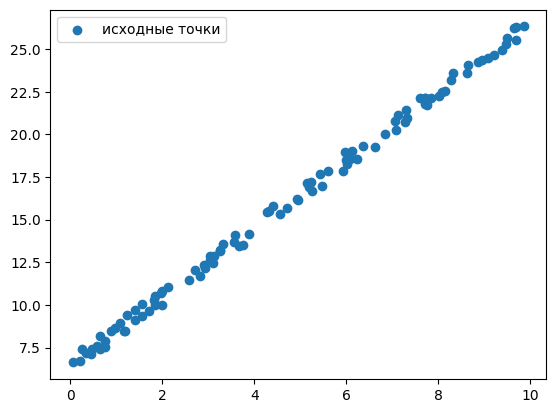

In [8]:
n = 100
slope = 2
bias = 6
mult = 10
oos_2_bias = 10

x = np.random.random(n)*mult
y = x * slope + bias + np.random.random(n)

sc = plt.scatter(x, y, label='исходные точки')
_ = plt.legend()

Сгенерим еще пару OOS для теста

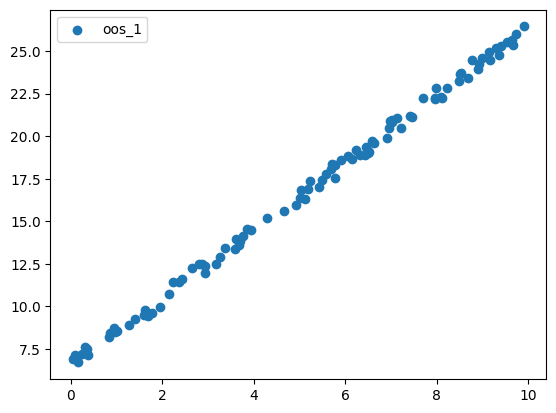

In [9]:
oos_x_1 = np.random.random(n)*mult
oos_y_1 = oos_x_1 * slope + bias + np.random.random(n)
_ = plt.scatter(oos_x_1, oos_y_1, label = 'oos_1')
_ = plt.legend()

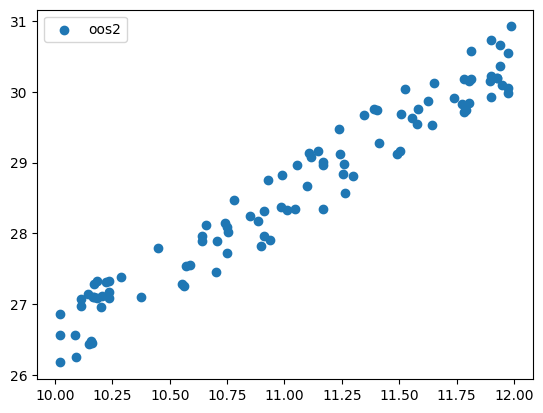

In [10]:
oos_x_2 = (np.random.random(n)*slope + oos_2_bias )
oos_y_2 = oos_x_2 * slope + bias + np.random.random(n)
_ = plt.scatter(oos_x_2, oos_y_2, label = 'oos2')
plt.legend()

А теперь все вместе

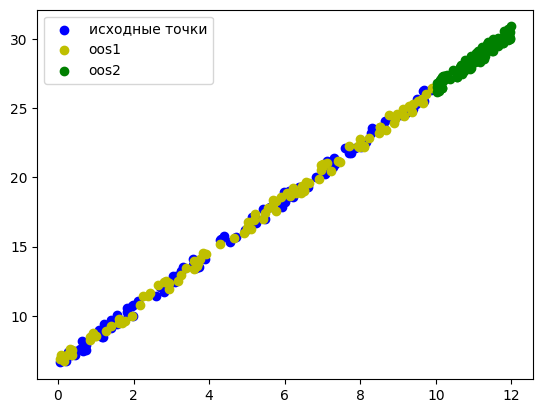

In [11]:
plt.scatter(x, y, c = 'b', label = 'исходные точки')
plt.scatter(oos_x_1, oos_y_1, c = 'y', label = 'oos1')
plt.scatter(oos_x_2, oos_y_2, c = 'g', label = 'oos2')
_ = plt.legend()

Проверим как линейная регрессия справится с обоими тестовыми множествами

0.9974842479666531
0.9438305194669983


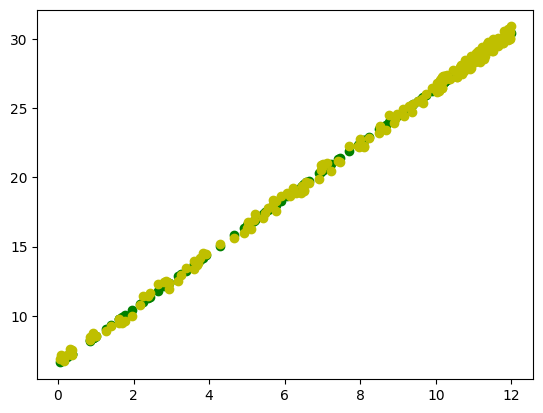

In [12]:
lr = LinearRegression()
lr.fit(x.reshape(-1,1), y)

print(lr.score(oos_x_1.reshape(-1,1), oos_y_1))
print(lr.score(oos_x_2.reshape(-1,1), oos_y_2))

_ = plt.scatter(oos_x_1, lr.predict(oos_x_1.reshape(-1,1)), c='g')
_ = plt.scatter(oos_x_2, lr.predict(oos_x_2.reshape(-1,1)), c='g')
_ = plt.scatter(oos_x_1, oos_y_1, c='y')
_ = plt.scatter(oos_x_2, oos_y_2, c='y')

Линейная регрессия справилась отлично! Теперь подключим LGBM



In [13]:
dt = XGBRegressor()
_ = dt.fit(x.reshape(-1,1),y, verbose = False)
print(dt.score(oos_x_1.reshape(-1,1), oos_y_1))
print(dt.score(oos_x_2.reshape(-1,1), oos_y_2))

0.9943678637859522
-3.2194567439466404


Ого! кто скажет что случилось?

Нарисуем?

0.9943678637859522
-3.2194567439466404


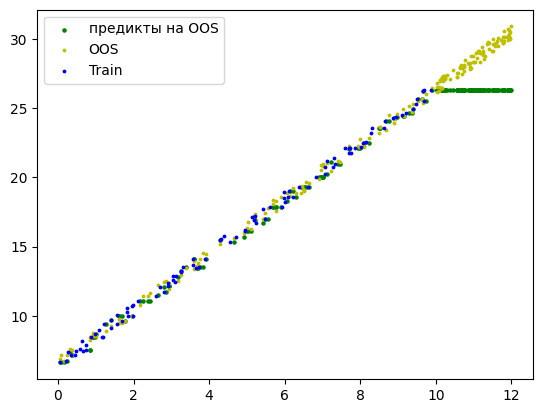

In [14]:
print(dt.score(oos_x_1.reshape(-1,1), oos_y_1))
print(dt.score(oos_x_2.reshape(-1,1), oos_y_2))
plt.scatter(oos_x_1, dt.predict(oos_x_1.reshape(-1,1)), c='g', label='предикты на OOS', s = 5)
plt.scatter(oos_x_2, dt.predict(oos_x_2.reshape(-1,1)), c='g', s = 5)
plt.scatter(oos_x_1, oos_y_1, c='y', label='OOS', s = 3)
plt.scatter(oos_x_2, oos_y_2, c='y', s = 3)

plt.scatter(x, y, c='b', label='Train', s = 3)
_ = plt.legend()

Кто может объяснить? Как починить?

In [15]:
dt2 = XGBRegressor(booster = 'gblinear')
_ = dt2.fit(x.reshape(-1,1),y, verbose = False)
print(dt2.score(oos_x_1.reshape(-1,1), oos_y_1))
print(dt2.score(oos_x_2.reshape(-1,1), oos_y_2))

0.9974847930100482
0.9438131808447259


Стало лучше! нарисуем

0.9974847930100482
0.9438131808447259


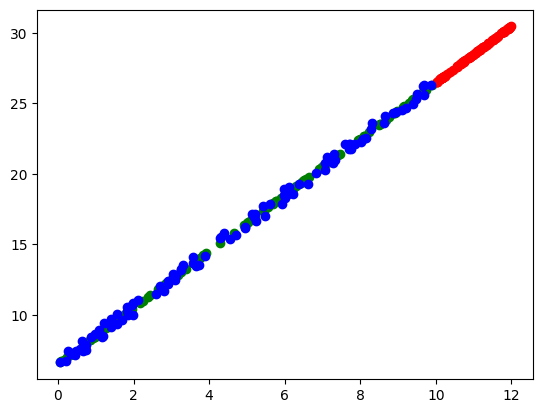

In [16]:
print(dt2.score(oos_x_1.reshape(-1,1), oos_y_1))
print(dt2.score(oos_x_2.reshape(-1,1), oos_y_2))
_ = plt.scatter(oos_x_1, dt2.predict(oos_x_1.reshape(-1,1)), c='g')
_ = plt.scatter(oos_x_2, dt2.predict(oos_x_2.reshape(-1,1)), c='r')
_ = plt.scatter(x, y, c='b')

А в LightGBM так просто и не починишь )

На подумать -- как именно работает градиентный бустинг над линейными моделями?

Про бизнес? Вы уверены что на инференсе не придет цена больше максимальной из трейна (точнее больше наибольшей средней в листах)?

# Новый раздел

# 2. Еще про границы применимости моделей -- с интерполяцией тоже не так гладко

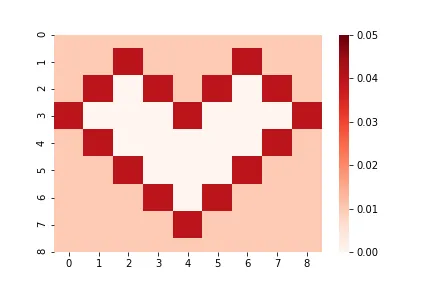

[сердечки в катбусте](https://github.com/catboost/catboost/blob/master/catboost/tutorials/uncertainty/uncertainty_regression.ipynb)

[и еще сердечки](https://towardsdatascience.com/tutorial-uncertainty-estimation-with-catboost-255805ff217e)

[Ын-буст NGBoost](https://stanfordmlgroup.github.io/projects/ngboost/)

In [17]:
!pip install catboost -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [18]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
np.random.seed(42)

In [19]:
n_features = 10
n_samples = 20000
data = make_regression(n_samples = n_samples, n_features =n_features, random_state = 42)
df = pd.DataFrame(data[0], columns = [f'feature_{k}' for k in range(n_features)])
df['target'] = data[1]

In [20]:
x_train, x_test, y_train, y_test = train_test_split(df.drop(['target'], axis = 1), df['target'], test_size=0.3, random_state=42)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.2, random_state=42)
train_pool = Pool(x_train, y_train)
val_pool = Pool(x_val, y_val)
cbr = CatBoostRegressor(
                          loss_function='RMSE', posterior_sampling=True,
                          verbose=False, random_seed=42)
cbr.fit(train_pool, eval_set=val_pool, verbose = False)
print(mean_squared_error(y_test, cbr.predict(x_test)))

87.24930842021628


In [21]:
model = CatBoostRegressor(
                          loss_function='RMSEWithUncertainty', posterior_sampling=True,
                          verbose=False, random_seed=42)
model.fit(train_pool, eval_set=val_pool)
preds = model.virtual_ensembles_predict(x_test, prediction_type='TotalUncertainty',
                                        virtual_ensembles_count=10)


res = pd.DataFrame(preds, columns = ['predictions', 'knowledge_uncertainty', 'data_uncertainty'], index = x_test.index)
res['target'] = y_test

In [22]:
print(mean_squared_error(res['target'], res['predictions']))

110.60808659036958


почему вышло хуже?
в ДЗ )

In [23]:
number_unc_bins = 20
res['unc_bin'] = pd.qcut(res['data_uncertainty'], number_unc_bins, labels = range(0, number_unc_bins))
mse = []
for tr in range(number_unc_bins):
  mse.append(mean_squared_error(res[res['unc_bin'] <= tr]['target'], res[res['unc_bin'] <= tr]['predictions']))

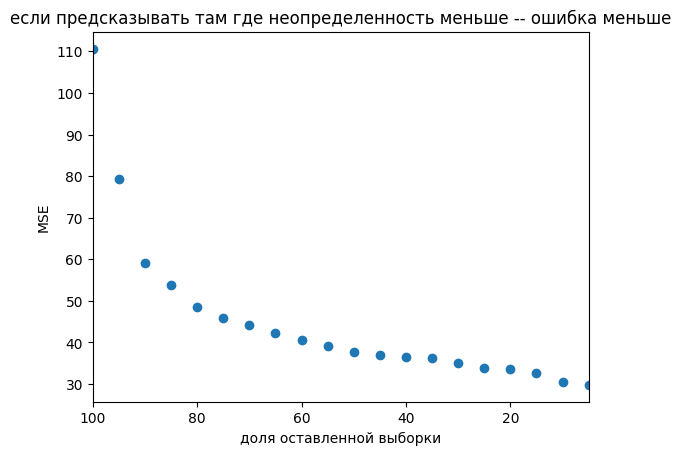

In [24]:
x_axis = np.linspace(5, 100, 20)
_ = plt.scatter(x_axis, mse)
plt.xlim(max(x_axis), min(x_axis))
plt.xlabel('доля оставленной выборки')
plt.ylabel('MSE')
plt.title('если предсказывать там где неопределенность меньше -- ошибка меньше')
plt.show()

Развитие подхода -- использовать не только оценку самого алгоритма, но и строить другую модель, которая на каждом семпле будет предсказывать ошибки текущей. Широко используется в банках как замена мониторинга моделей -- MPP

Например, в [статье](https://habr.com/ru/companies/vtb/articles/505892/) коллег из ВТБ

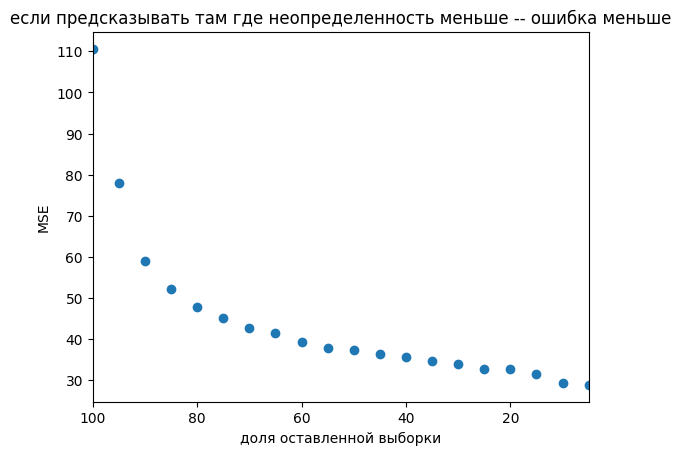

In [25]:
res['total_uncertaincy'] = res['data_uncertainty'] + res['knowledge_uncertainty']
number_unc_bins = 20
res['unc_bin_total'] = pd.qcut(res['total_uncertaincy'], number_unc_bins, labels = range(0, number_unc_bins))
mse_total = []
for tr in range(number_unc_bins):
  mse_total.append(mean_squared_error(res[res['unc_bin_total'] <= tr]['target'], res[res['unc_bin_total'] <= tr]['predictions']))
x_axis = np.linspace(5, 100, 20)
_ = plt.scatter(x_axis, mse_total)
plt.xlim(max(x_axis), min(x_axis))
plt.xlabel('доля оставленной выборки')
plt.ylabel('MSE')
plt.title('если предсказывать там где неопределенность меньше -- ошибка меньше')
plt.show()

# 3. Раз уж зашло про деревянные алгоритмы -- у них тоже есть особенности


немного про RF

In [26]:
from sklearn.datasets import make_classification
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_features = 500
n_samples = 2000
data = make_classification(n_samples = n_samples, n_features =n_features, random_state = 42, n_redundant = n_features - n_features // 4)
df = pd.DataFrame(data[0], columns = [f'feature_{k}' for k in range(n_features)])
df['target'] = data[1]
df['feature_1'] = df['target'] + 0.5* df['feature_1']
df.rename(columns={'feature_1':'killer'}, inplace = True)

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

In [28]:
x_train, x_test, y_train, y_test = train_test_split(df.drop('target', axis = 1), df['target'], test_size=0.33, random_state=42)

In [29]:
rf = RandomForestClassifier(random_state = 42)
rf.fit(x_train, y_train,)
print(rf.score(x_test, y_test))

0.9515151515151515


In [30]:
from sklearn.tree import DecisionTreeClassifier

In [31]:
dtc = DecisionTreeClassifier(random_state=42)

In [32]:
dtc.fit(x_train, y_train)
print(dtc.score(x_test, y_test))

0.990909090909091


Почему единичное дерево лучше работает?

In [33]:
sorted([[col, imp] for imp, col in zip(rf.feature_importances_, \
                                       df.drop('target', axis = 1).columns)], key = lambda x :x[1], reverse=True)[0:5]

[['killer', np.float64(0.09535671897495712)],
 ['feature_197', np.float64(0.027330275334180927)],
 ['feature_324', np.float64(0.02708473592456345)],
 ['feature_182', np.float64(0.02678941890217905)],
 ['feature_437', np.float64(0.025746954477203696)]]

In [34]:
sorted([[col, imp] for imp, col in zip(dtc.feature_importances_, \
                                       df.drop('target', axis = 1).columns)], key = lambda x :x[1], reverse=True)[0:5]

[['killer', np.float64(0.9210908320087833)],
 ['feature_360', np.float64(0.05260854827649881)],
 ['feature_86', np.float64(0.009594904103468391)],
 ['feature_87', np.float64(0.00785978035708908)],
 ['feature_370', np.float64(0.0029802588513088406)]]

Почему так?
RF стоит на трех китах:

*   subsampling (выкидываем часть точек при построении очередного дерева),
*   subspacing (выкидываем часть фичей при построении очередного дерева),
*   voting (осредняем предикты всех деревьев)

Ситуации когда хорошая фича или важная группа сэмплов падает жертвой bagging / undersampling etc -- более чем частая


# 4. Фит-предикт -- путь к провалу

In [35]:
!pip install catboost -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [36]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [37]:
np.random.seed(42)
n_samples = 10000

x = np.linspace(0, 10, n_samples).reshape(-1, 1)
y = 3 * np.sin(x) * x + 10 * x + np.random.normal(0, 0.5, size=(n_samples, 1))

df = pd.DataFrame({'feature': x.flatten(), 'target': y.flatten()})

df['feature'] = df['feature'] ** 2
x_train, x_test, y_train, y_test = train_test_split(df[['feature']], df['target'], test_size=0.2, random_state=42)

train_pool = Pool(x_train, y_train)

Кто-нибудь помнит как выбираются делаются сплиты?

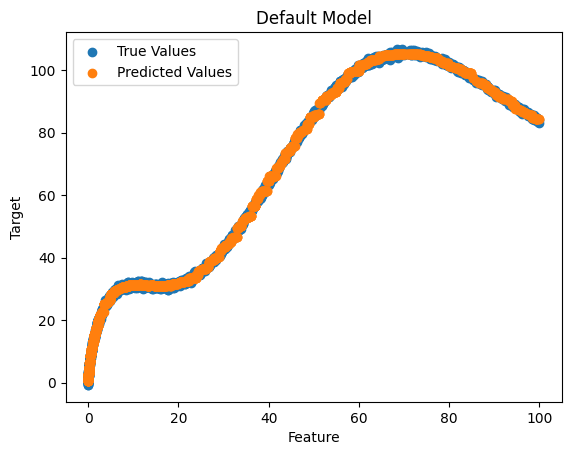

Default Model - Mean Squared Error: 0.47853450806524234


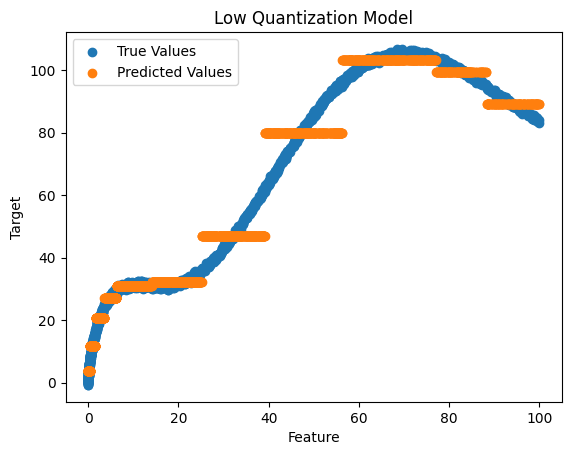

Low Quantization Model - Mean Squared Error: 24.644833954656363


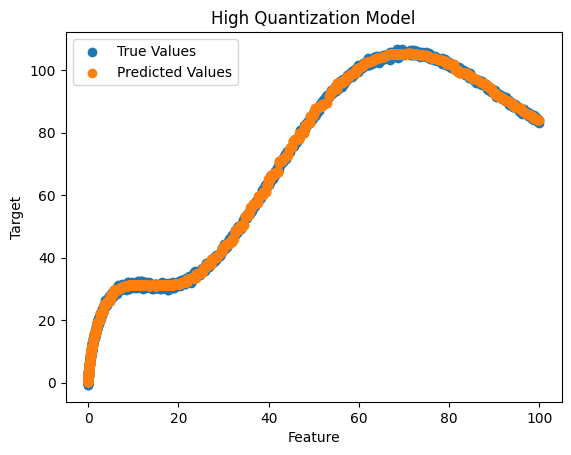

High Quantization Model - Mean Squared Error: 0.4175311130008739


In [38]:
catboost_params_default = {
    'iterations': 100,
    'learning_rate': 0.1,
    'depth': 6,
    'loss_function': 'RMSE',
}

catboost_params_custom_low_quantization = {
    'iterations': 100,
    'learning_rate': 0.1,
    'depth': 6,
    'loss_function': 'RMSE',
    'per_float_feature_quantization': ['0:border_count=10'],  # Low quantization
}

catboost_params_custom_high_quantization = {
    'iterations': 100,
    'learning_rate': 0.1,
    'depth': 6,
    'loss_function': 'RMSE',
    'per_float_feature_quantization': ['0:border_count=4096'],  # High quantization
}

models = []

model_default = CatBoostRegressor(**catboost_params_default)
model_default.fit(train_pool, verbose = False)
models.append(('Default', model_default))

model_low_quantization = CatBoostRegressor(**catboost_params_custom_low_quantization)
model_low_quantization.fit(train_pool, verbose = False)
models.append(('Low Quantization', model_low_quantization))

model_high_quantization = CatBoostRegressor(**catboost_params_custom_high_quantization)
model_high_quantization.fit(train_pool, verbose = False)
models.append(('High Quantization', model_high_quantization))

mse_array = {}

for model_name, model in models:
    y_pred = model.predict(x_test)

    plt.scatter(x_test, y_test, label='True Values')
    plt.scatter(x_test, y_pred, label='Predicted Values')
    plt.xlabel('Feature')
    plt.ylabel('Target')
    plt.title(f'{model_name} Model')
    plt.legend()
    plt.show()

    mse = mean_squared_error(y_test, y_pred)
    mse_array[model_name] = mse
    print(f'{model_name} Model - Mean Squared Error: {mse}')

Golden features? Quantization?

Это не про глубину деревьев и не про их число

In [39]:
round((1 - mse_array['High Quantization'] / mse_array['Default']) * 100)

13

На 13% уменьшили ошибку

---





[Пример когда дефолтное число сплитов сломало ценообразование на маркетплейсе](https://habr.com/ru/articles/760550/)



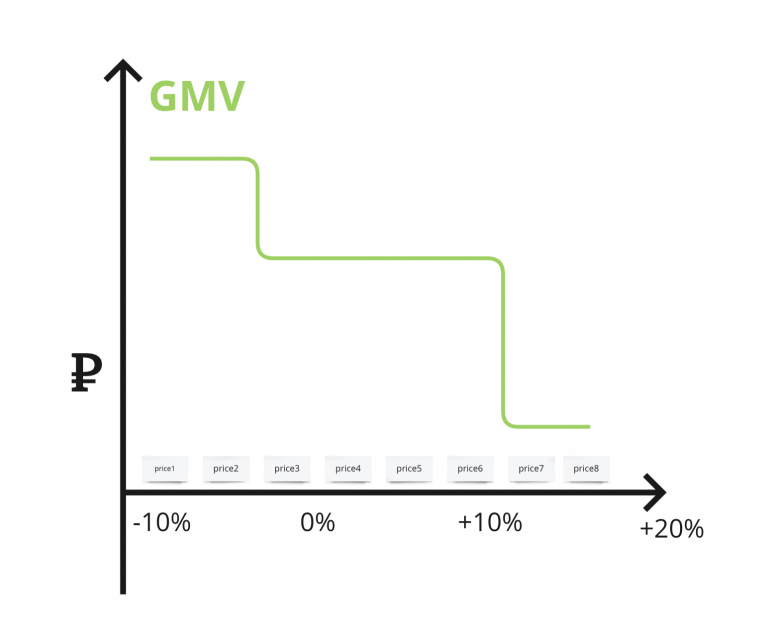

# 5. Как валидироваться

ML в бизнесе это в тч про то, чтобы деливерить стабильный прогнозируемый результат, и у каждой бизнес-задачи могут быть свои требования к проверке моделей перед их использованием.

В курсе мы подробно рассмотрим как в бизнес-задачах проверяют модель на

*   Переобученность
*   Стабильность во времени в смысле
    *   Data drift (часто называют Covariate shift)
    *   Concept Drift (posterior shift)
    *   Target shift (label shift, prior shift)
*   Соответсвие бизнес-логике и монотонным ограничениям
*   Интерпретируемость
*   Уверенность модели в ответе (uncertaincy и confidence)

а пока рассмотрим базовые подходы к валидации моделей  (с учетом что вы уже знаете про кросс-валидацию, метрики и отложенный тест)



## 5.1. Stratified vs group k-fold

In [40]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
np.random.seed(42)

In [41]:
x, y = make_classification(
    n_samples=1000,
    n_features=5,
    n_informative=3,
    n_redundant=1,
    n_clusters_per_class=1,
    flip_y=0.1,
    random_state=42
)

num_groups = 10
group_ids = np.random.randint(num_groups, size=len(y))

data = pd.DataFrame(data={'feature_{}'.format(i): x[:, i] for i in range(x.shape[1])})
data['target'] = y
data['group_id'] = group_ids
cnt_dict = dict(data['group_id'].value_counts())
print(data.head())

   feature_0  feature_1  feature_2  feature_3  feature_4  target  group_id
0   0.798544   2.280978  -0.822322   0.288411  -3.418566       1         6
1   1.405951   0.664275   0.451591  -0.704822   0.577618       1         3
2  -1.964415   1.325393   0.827029   1.040189  -0.808016       0         7
3   1.792585   1.604088  -0.271690  -0.134156  -1.431986       1         4
4  -1.246207   0.364518   0.128635  -0.358704  -0.654848       1         6


Как правильно тестироваться?   
Группы постоянные (ex: Регионы)?   




Fold 1:
Training samples: 800
Testing samples: 200
Unique groups in training set: 10
Unique groups in testing set: 10

Fold 2:
Training samples: 800
Testing samples: 200
Unique groups in training set: 10
Unique groups in testing set: 10

Fold 3:
Training samples: 800
Testing samples: 200
Unique groups in training set: 10
Unique groups in testing set: 10

Fold 4:
Training samples: 800
Testing samples: 200
Unique groups in training set: 10
Unique groups in testing set: 10

Fold 5:
Training samples: 800
Testing samples: 200
Unique groups in training set: 10
Unique groups in testing set: 10


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/model_selection/_split.py:883: UserWarning: The groups parameter is ignored by StratifiedKFold
  warnings.warn(


Text(0.5, 0.98, 'доли групп в трейне')

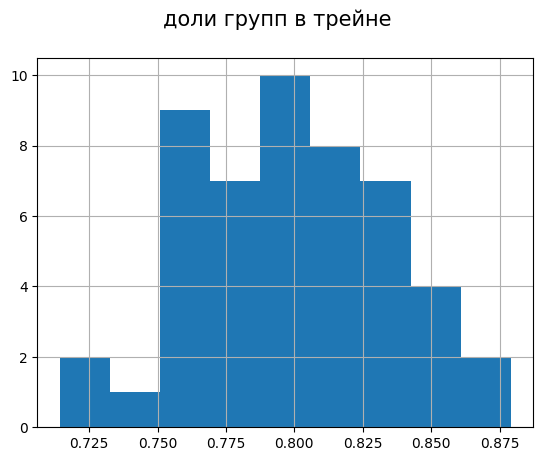

In [42]:
from sklearn.model_selection import StratifiedKFold
k_fold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ratios = []
for fold, (train_indices, test_indices) in enumerate(k_fold.split(x, y, group_ids)):
    print(f"\nFold {fold + 1}:")
    print(f"Training samples: {len(train_indices)}")
    print(f"Testing samples: {len(test_indices)}")
    print(f"Unique groups in training set: {len(np.unique(group_ids[train_indices]))}")
    print(f"Unique groups in testing set: {len(np.unique(group_ids[test_indices]))}")

    train_cnt_dict = dict(pd.Series(group_ids[train_indices]).value_counts())
    for group in train_cnt_dict:
      ratios.append(train_cnt_dict[group] * 1.0 / cnt_dict[group])
fig = plt.figure()
pd.Series(ratios).hist(bins = 9)
fig.suptitle('доли групп в трейне', fontsize=15)

Или на инференсе новая группа может придти (в ЖК есть корпуса а в них квартиры)?

In [43]:
from sklearn.model_selection import GroupKFold
k_fold = GroupKFold(n_splits=5)

for fold, (train_indices, test_indices) in enumerate(k_fold.split(x, y, group_ids)):
    print(f"\nFold {fold + 1}:")
    print(f"Training samples: {len(train_indices)}")
    print(f"Testing samples: {len(test_indices)}")
    print(f"Unique groups in training set: {len(np.unique(group_ids[train_indices]))}")
    print(f"Unique groups in testing set: {len(np.unique(group_ids[test_indices]))}")


Fold 1:
Training samples: 799
Testing samples: 201
Unique groups in training set: 8
Unique groups in testing set: 2

Fold 2:
Training samples: 799
Testing samples: 201
Unique groups in training set: 8
Unique groups in testing set: 2

Fold 3:
Training samples: 799
Testing samples: 201
Unique groups in training set: 8
Unique groups in testing set: 2

Fold 4:
Training samples: 799
Testing samples: 201
Unique groups in training set: 8
Unique groups in testing set: 2

Fold 5:
Training samples: 804
Testing samples: 196
Unique groups in training set: 8
Unique groups in testing set: 2


чтобы в явном виде задать сколько групп не включать в тексст -- [Leave P Groups Out](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.LeavePGroupsOut.html#sklearn.model_selection.LeavePGroupsOut)

## 5.2 Двойная кросс-валидация

Утащено [отсюда](https://machinelearningmastery.com/nested-cross-validation-for-machine-learning-with-python/)

In [44]:
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

In [45]:
%%time
random_state = 42
# create dataset
x, y = make_classification(n_samples=1000, n_features=20, random_state=1, n_informative=10, n_redundant=10)
# configure the cross-validation procedure
cv_inner = KFold(n_splits=3, shuffle=True, random_state=random_state)
# define the model
model = RandomForestClassifier(random_state=random_state)
# define search space
space = dict()
space['n_estimators'] = [10, 100]
space['max_features'] = [2, 4, 6]
# define search
search = GridSearchCV(model, space, scoring='accuracy', n_jobs=1, cv=cv_inner, refit=True)
# configure the cross-validation procedure
cv_outer = KFold(n_splits=3, shuffle=True, random_state=1) # 10
# execute the nested cross-validation
scores = cross_val_score(search, x, y, scoring='accuracy', cv=cv_outer, n_jobs=-1)
# report performance
print('Accuracy: %.3f (%.3f)' % (mean(scores), std(scores)))

Accuracy: 0.927 (0.004)
CPU times: user 25.3 ms, sys: 78.1 ms, total: 103 ms
Wall time: 3.53 s


А вообще только в [2018](https://arxiv.org/abs/1809.09446) поставили точку в нужности такого приема (а их было много -- CV со взвешиваниями, со штрафами (V-Fold CV with penalty) и пр.)

## 5.3. Валидация с учетом времени

Простая схема с OOT
[отсюда](https://forecastegy.com/posts/time-series-cross-validation-python/)
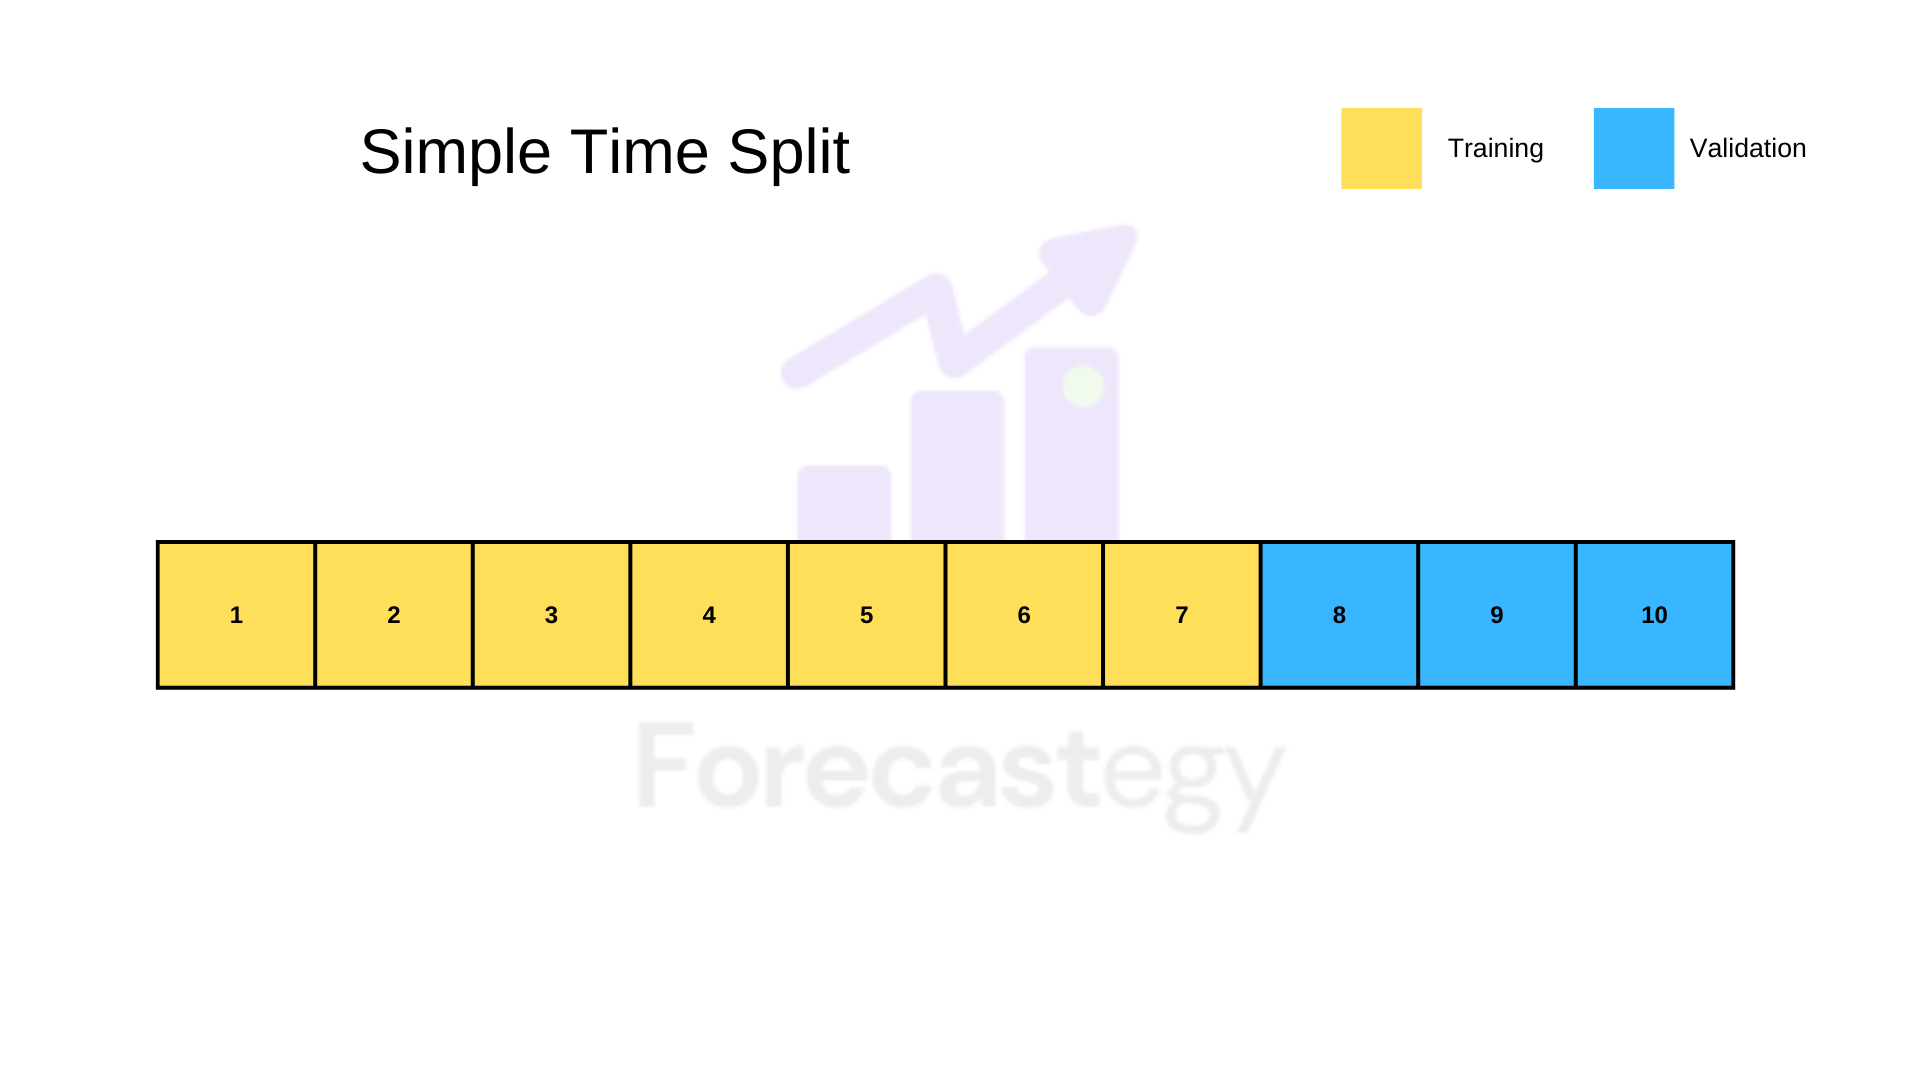

Схема скользящего окна
[отсюда](https://forecastegy.com/posts/time-series-cross-validation-python/)

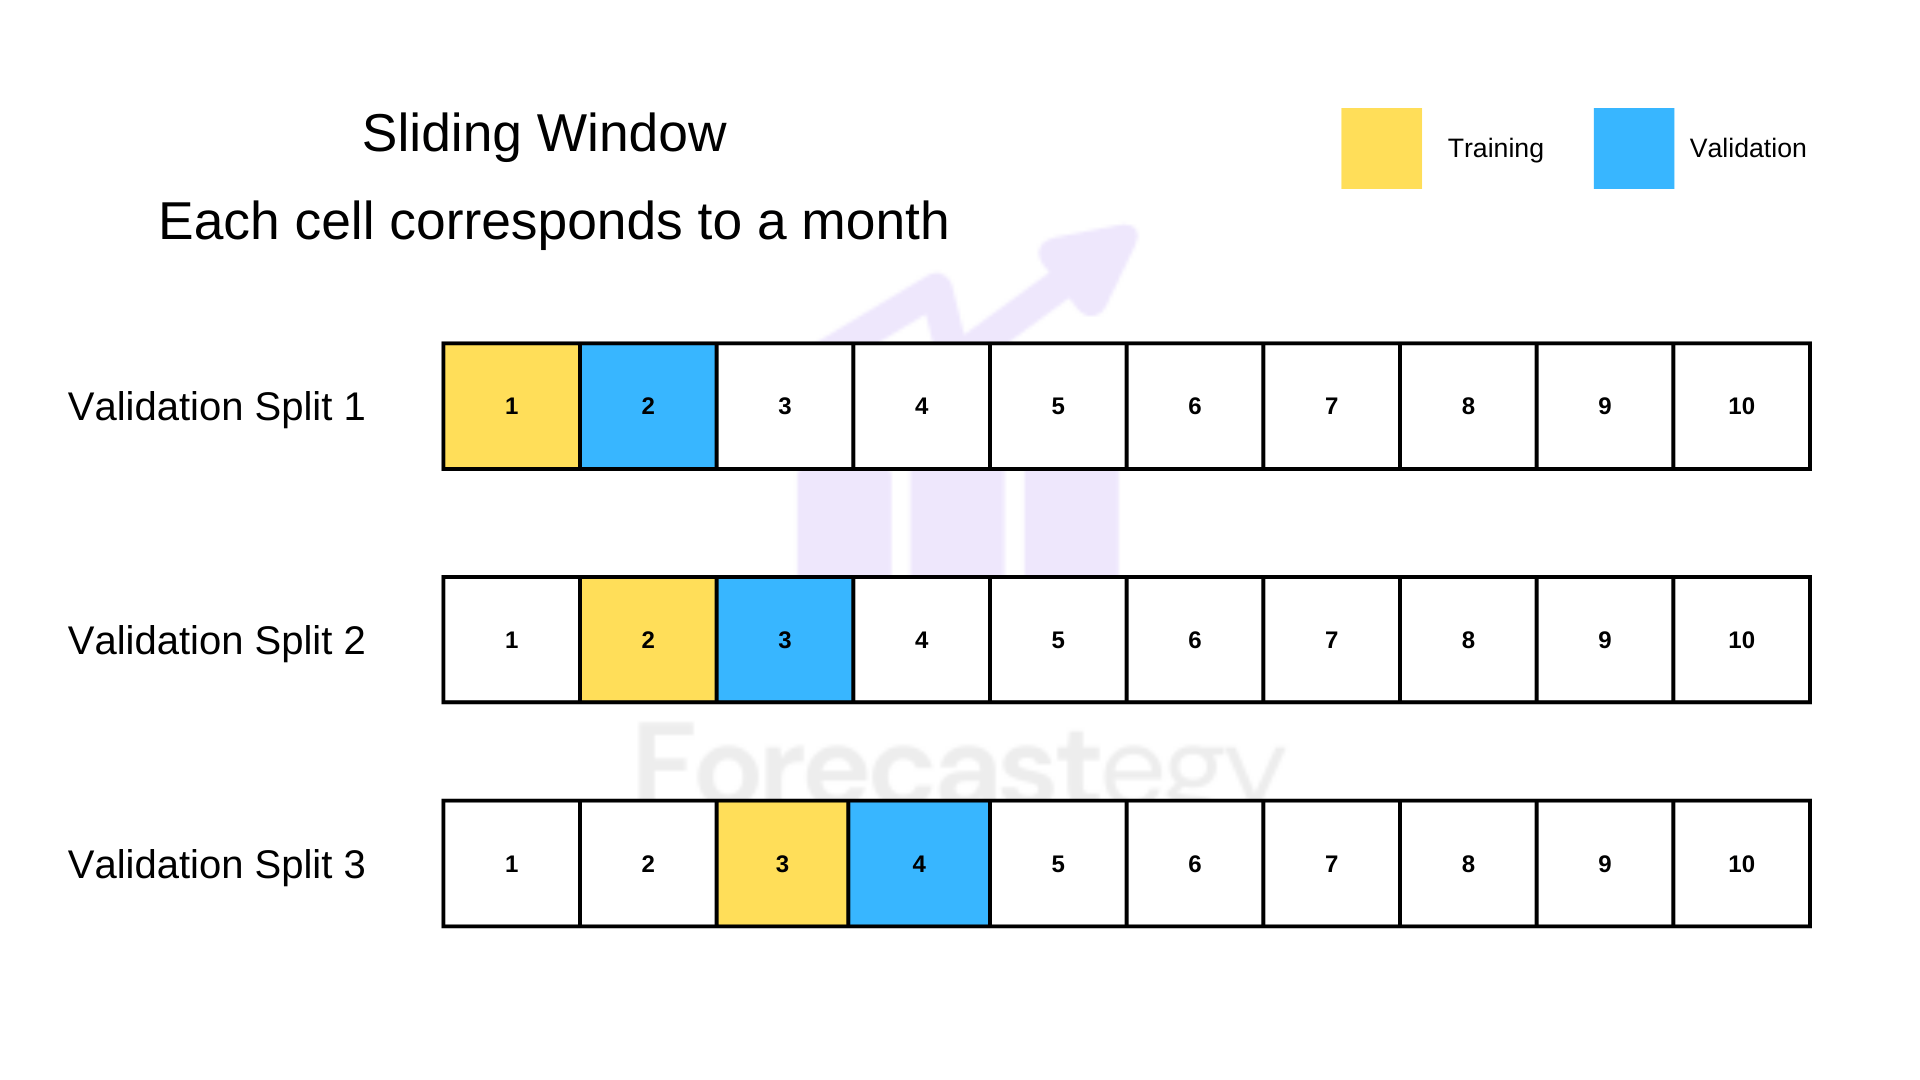

Схема расширяющегося скользящего окна
[отсюда](https://forecastegy.com/posts/time-series-cross-validation-python/)

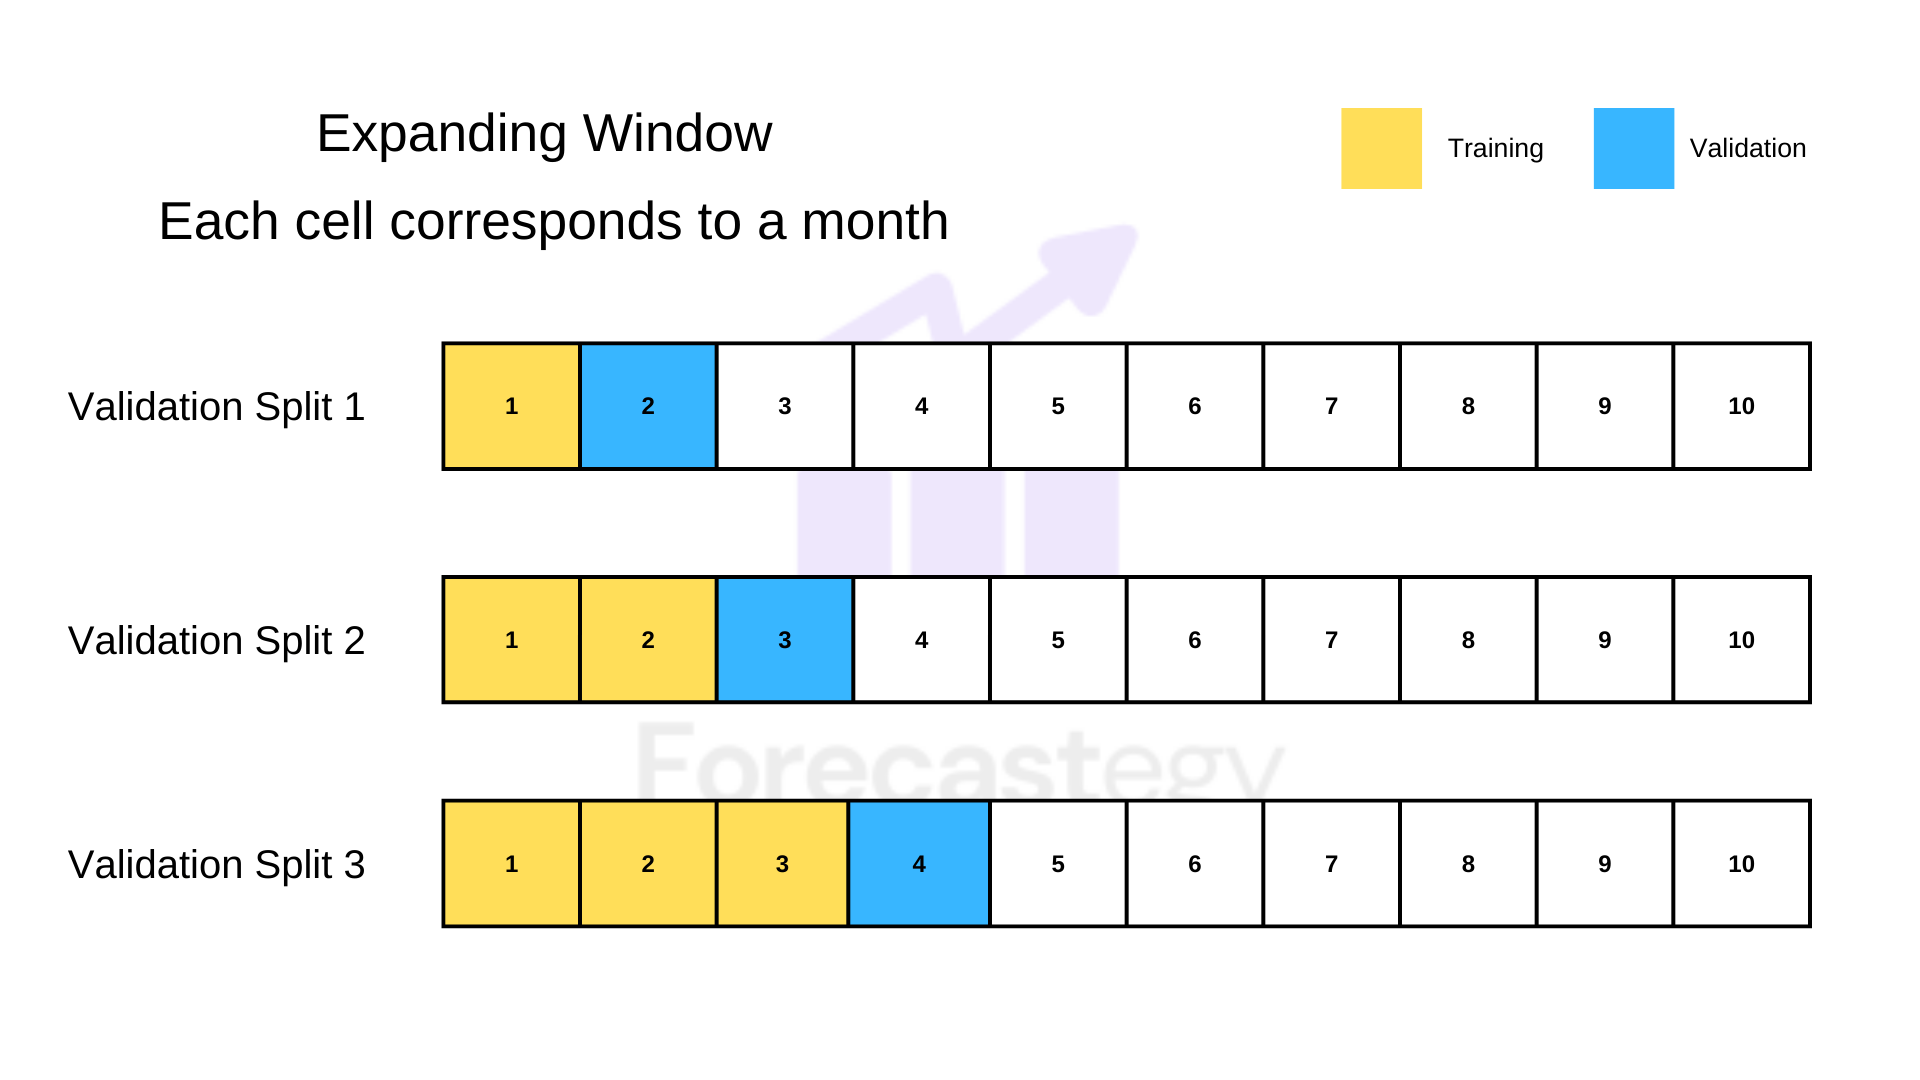

Схема скользящего окна с зазором
[отсюда](https://forecastegy.com/posts/time-series-cross-validation-python/)

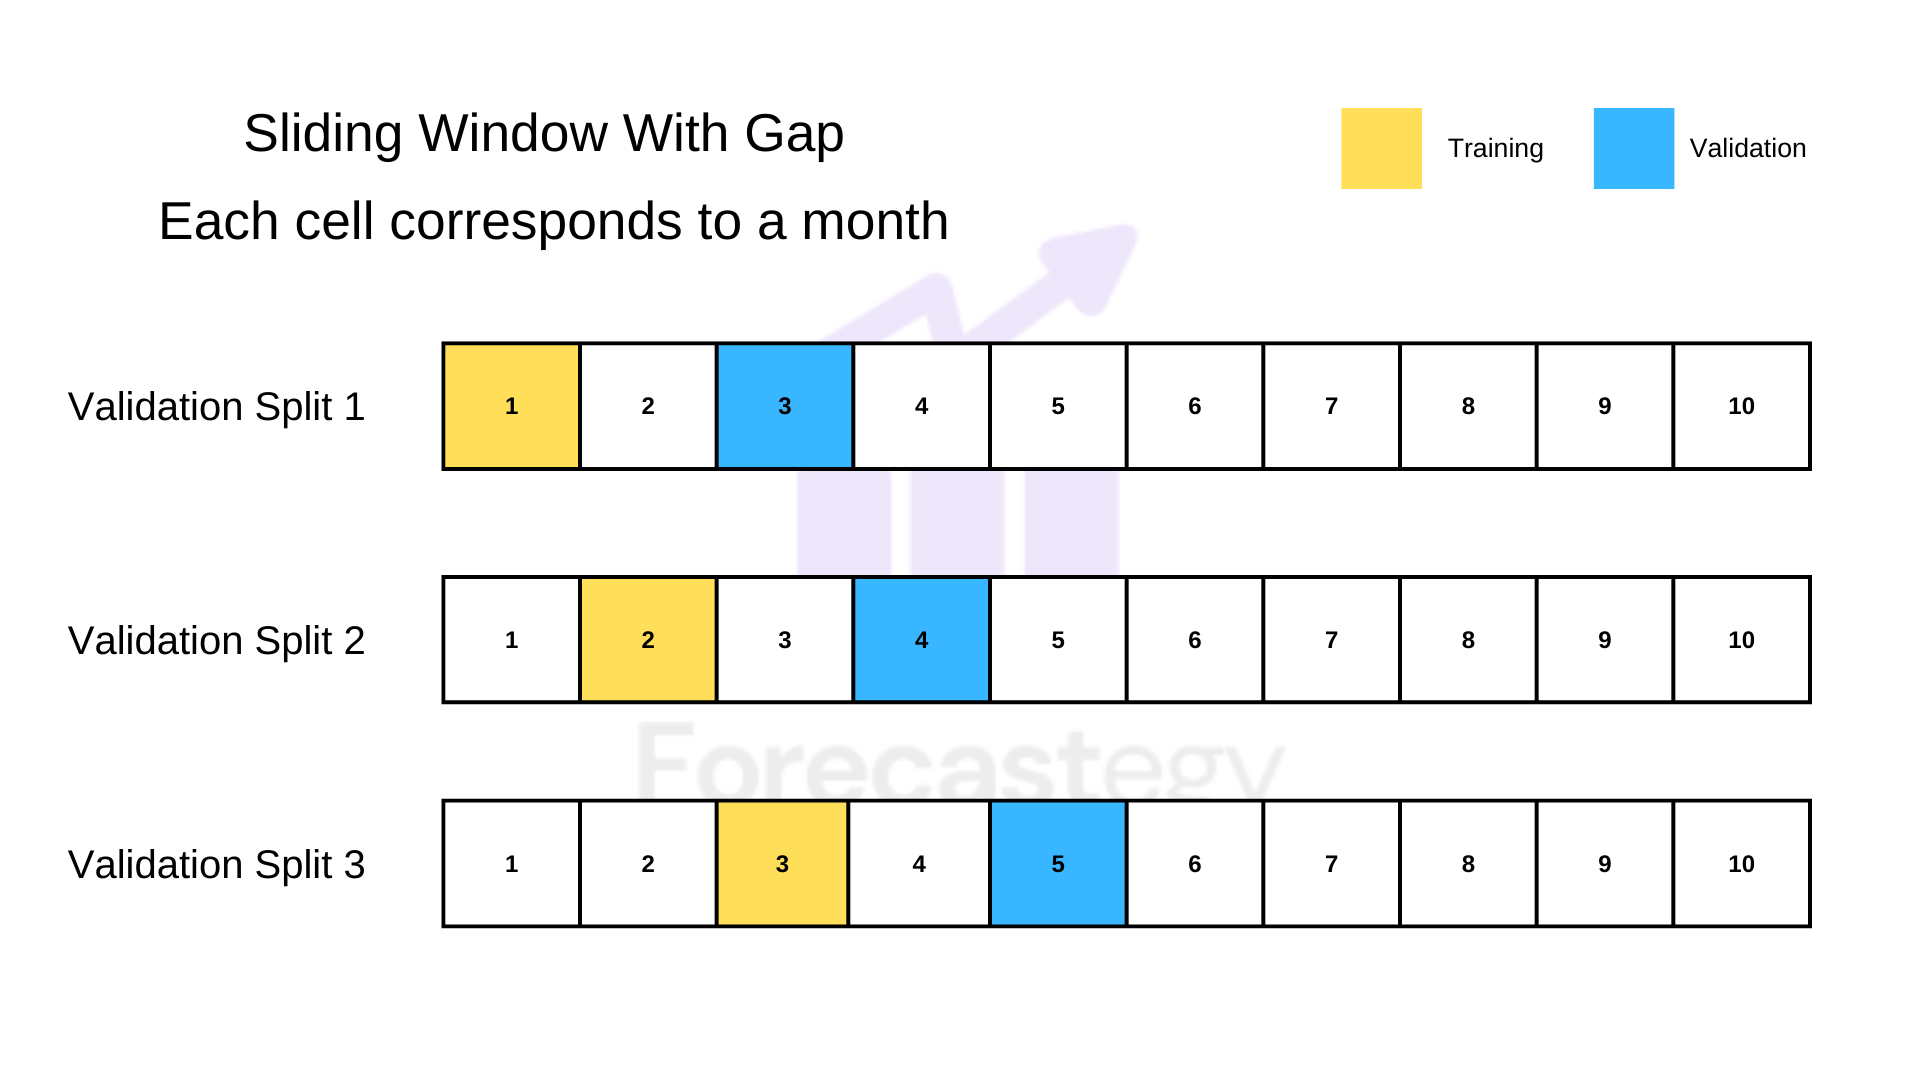

Какая схема чаще всего на практике?

Очень важно запомнить последнюю и всегда учитывать лаг источника как при сборке трейна, так и при валидации!

Параметр Gap уже появился и в sklearn в [TimeSeriesSplit](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.TimeSeriesSplit.html#sklearn.model_selection.TimeSeriesSplit)

## 5.4. Валидация двухэтапной модели

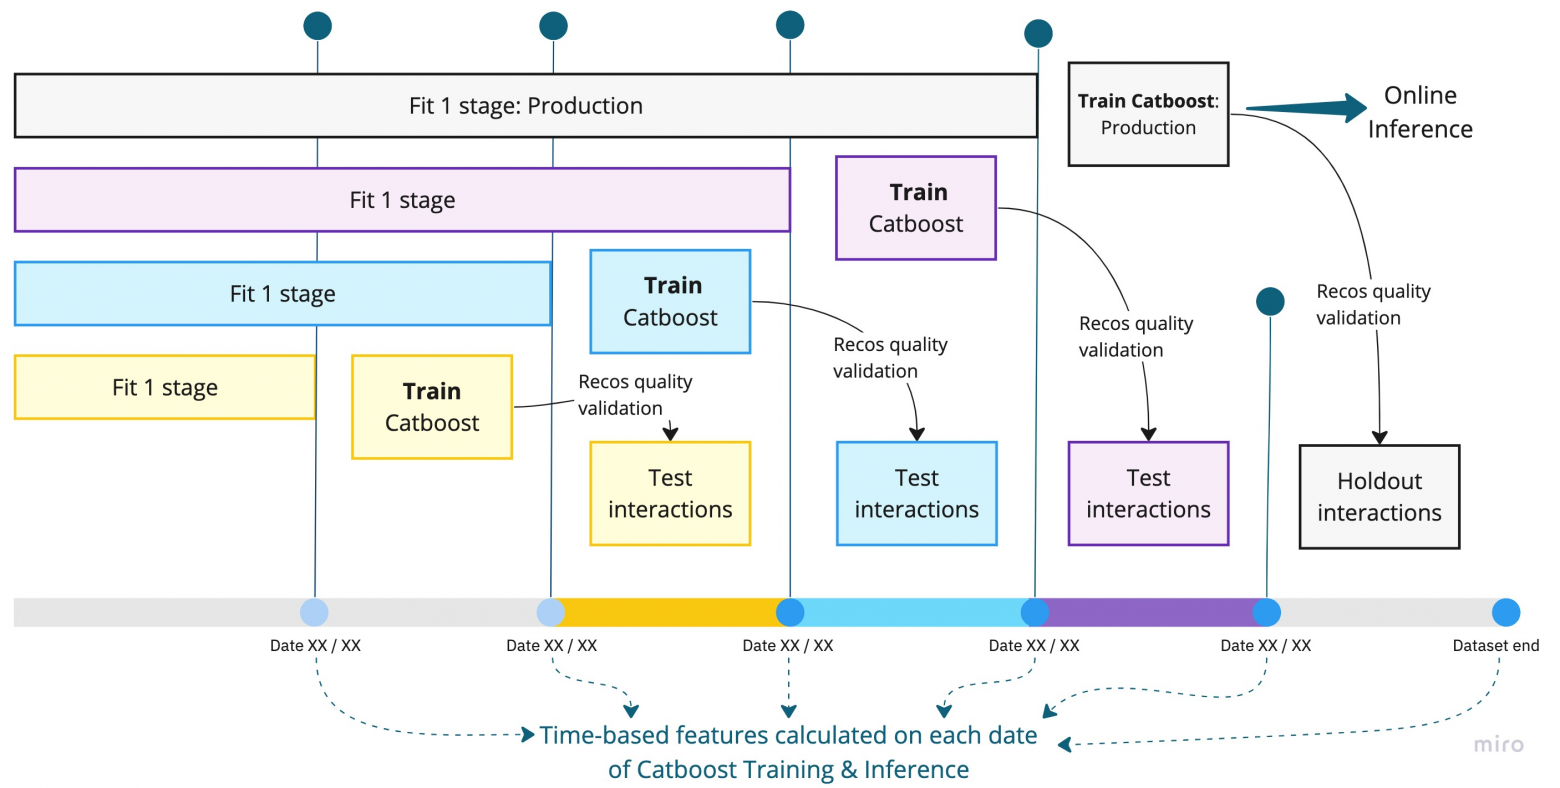


чуть детальнее про такие модели в рекомендациях [в блоге МТС на habr](https://habr.com/ru/companies/ods/articles/756874/)

## 5.5. Repeated k-fold

In [46]:
import lightgbm as lgb
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import uniform
from sklearn.metrics import accuracy_score
from tqdm import tqdm

Пара экспериментов

### Эксперимент 1.

Разделим выборку на train и test.      
И на трейне будем через cv подбирать гиперпараметры, задав не по сетке всего один -- L2-регуляризию весов листьев в бустинге и подбирая его через RandomizedSearch.

Попробуем проверить, что произойдет с точностью модели если попробовать 200 разных random_state только для этой процедуры -- все остальное (разделение на train/test, сетка параметров и пр. -- абсолютно одинаковое)

In [47]:
%%time
res_test_metrics = []
x, y = make_classification(n_samples=5000, n_features=20, random_state=1, n_informative=10, n_redundant=10)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

for random_state in tqdm(range(200)):
  bst = lgb.LGBMClassifier()
  hyper_space = dict(max_depth = [10, 15]
                    , n_estimators = [50, 100, 200]
                    , reg_lambda = uniform(), verbose = [-1], num_leaves=[32])
  clf = RandomizedSearchCV(bst, hyper_space, random_state=random_state)
  search = clf.fit(x_train, y_train)
  bst = lgb.LGBMClassifier(**search.best_params_)
  bst.fit(x_train, y_train)
  res_test_metrics.append(accuracy_score(bst.predict(x_test), y_test))
  print('accuracy ',  res_test_metrics[-1])

  0%|          | 0/200 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Vers

accuracy  0.958


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/

CPU times: user 27.2 s, sys: 1min 56s, total: 2min 23s
Wall time: 40.4 s


KeyboardInterrupt: 

In [ ]:
print( min(res_test_metrics), max(res_test_metrics))
# 0.953 0.963

0.953 0.963


### Эксперимент 2

А теперь возьмем стандратный пайп обучения модели с разделением на отложенную выборку и подбором гиперпараметров через кросс-валидацию и начнем менять random_state для откладывания выборки.
Что произойдет с точностью модели?

In [48]:
%%time
test_metrics_different_rs = []
for random_state in tqdm(range(200)):
  x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = random_state)
  bst = lgb.LGBMClassifier()
  hyper_space = dict(max_depth = [10, 15]
                    , n_estimators = [50, 100, 200]
                    , reg_lambda = uniform(), verbose = [-1], num_leaves=[32])
  clf = RandomizedSearchCV(bst, hyper_space, random_state=42)
  search = clf.fit(x_train, y_train)
  bst = lgb.LGBMClassifier(**search.best_params_)
  bst.fit(x_train, y_train)
  test_metrics_different_rs.append(accuracy_score(bst.predict(x_test), y_test))
  print(test_metrics_different_rs[-1])

  0%|          | 0/200 [00:00<?, ?it/s]/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Vers

CPU times: user 6.66 s, sys: 25.9 s, total: 32.5 s
Wall time: 10.2 s


KeyboardInterrupt: 

In [ ]:
print( min(test_metrics_different_rs), max(test_metrics_different_rs))
# 0.937 0.97

0.937 0.97


чтобы сделать k-fold еще более случайным придумали repeated k-fold

### Repeated K-Fold

Если хочется оценить разброс быстрее -- можно добавить побольше рандомизаций !

In [49]:
from sklearn.model_selection import RepeatedKFold

In [ ]:
%%time
res2_test_metrics = []
x, y = make_classification(n_samples=5000, n_features=20, random_state=1, n_informative=10, n_redundant=10)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
rkf = RepeatedKFold(n_splits=5, n_repeats=4, random_state=2652124)
random_state = 43
rkf.get_n_splits(x_train, y_train)
bst = lgb.LGBMClassifier(verbose = [-1])
for i, (train_index, test_index) in enumerate(rkf.split(x_train)):
  bst.fit(x_train[train_index], y_train[train_index])
  res2_test_metrics.append(accuracy_score(bst.predict(x_train[test_index]), y_train[test_index]))
  res2_test_metrics.append(accuracy_score(bst.predict(x_test), y_test))

In [ ]:
min(res2_test_metrics), max(res2_test_metrics)

(0.92875, 0.95875)

## 5.6. Как оценить качество модели на трейне? Out of fold валидация

Сейчас мы рассмотрим прием, связанный с оценкой качества модели на **трейне**

Сначала построим модель и оценим ее качество на **тесте**

In [51]:
import lightgbm as lgb
from numpy import mean
from numpy import std
from sklearn.datasets import make_classification
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import uniform
from sklearn.metrics import accuracy_score
from tqdm import tqdm

In [ ]:
res_test_metrics = []
random_state = 123
x, y = make_classification(n_samples=5000, n_features=20, random_state=random_state, n_informative=10, n_redundant=10)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_state)

bst = lgb.LGBMClassifier()
hyper_space = dict(max_depth = [10, 15]
                    , n_estimators = [50, 100, 200]
                    , reg_lambda = uniform(), verbose = [-1], num_leaves=[32])
clf = RandomizedSearchCV(bst, hyper_space, random_state=random_state)
search = clf.fit(x_train, y_train)
bst = lgb.LGBMClassifier(**search.best_params_)
bst.fit(x_train, y_train)
print(accuracy_score(bst.predict(x_test), y_test))

как часто (и редко когда оправданно) оценивают качество ошибки на трейне:

In [ ]:
print(accuracy_score(bst.predict(x_train), y_train))

1.0


Понятно, что бустинг склонен к переобучению, но даже достаточно загрубленный бустинг выдал бы оценку точности сильно выше, чем на тесте. Как же получить относительно честную оценку качества на трейне?

In [53]:
import pandas as pd
x_train_df = pd.DataFrame(x_train)
y_train_df = pd.Series(y_train)

In [ ]:
from sklearn.model_selection import KFold
kf = KFold(n_splits=5)
predictions = []
for cv_train_idx, cv_test_idx in kf.split(x_train):
  bst = lgb.LGBMClassifier(**search.best_params_)
  bst.fit(x_train[cv_train_idx], y_train[cv_train_idx])
  if len(predictions) == 0:
    predictions = pd.DataFrame(bst.predict(x_train[cv_test_idx]), index = cv_test_idx)
  else:
    predictions = pd.concat([predictions, pd.DataFrame(bst.predict(x_train[cv_test_idx]), index = cv_test_idx)])

In [ ]:
print(accuracy_score(predictions.sort_index(), y_train_df.sort_index()))

0.94875


Вот этот Out of fold скор часто называют оценкой качества модели на трейне

Но есть нюанс -- посмотрим на индексы, которые дает KFold:

In [ ]:
cv_test_idx

array([3200, 3201, 3202, 3203, 3204, 3205, 3206, 3207, 3208, 3209, 3210,
       3211, 3212, 3213, 3214, 3215, 3216, 3217, 3218, 3219, 3220, 3221,
       3222, 3223, 3224, 3225, 3226, 3227, 3228, 3229, 3230, 3231, 3232,
       3233, 3234, 3235, 3236, 3237, 3238, 3239, 3240, 3241, 3242, 3243,
       3244, 3245, 3246, 3247, 3248, 3249, 3250, 3251, 3252, 3253, 3254,
       3255, 3256, 3257, 3258, 3259, 3260, 3261, 3262, 3263, 3264, 3265,
       3266, 3267, 3268, 3269, 3270, 3271, 3272, 3273, 3274, 3275, 3276,
       3277, 3278, 3279, 3280, 3281, 3282, 3283, 3284, 3285, 3286, 3287,
       3288, 3289, 3290, 3291, 3292, 3293, 3294, 3295, 3296, 3297, 3298,
       3299, 3300, 3301, 3302, 3303, 3304, 3305, 3306, 3307, 3308, 3309,
       3310, 3311, 3312, 3313, 3314, 3315, 3316, 3317, 3318, 3319, 3320,
       3321, 3322, 3323, 3324, 3325, 3326, 3327, 3328, 3329, 3330, 3331,
       3332, 3333, 3334, 3335, 3336, 3337, 3338, 3339, 3340, 3341, 3342,
       3343, 3344, 3345, 3346, 3347, 3348, 3349, 33

Они идут подряд!!!

Это, кстати, позволит обойтись **без Pandas** в этом коде)

Однако, [Shuffle Split](https://scikit-learn.org/dev/modules/generated/sklearn.model_selection.ShuffleSplit.html#sklearn.model_selection.ShuffleSplit) здесь только навредит -- какие-то индексы могут вообще не попасть в тест ни разу, а какие-то дважды.

Так что если хотите перемешать данные -- лучше сделать это один раз до OOF оценки

Теперь давайте сравним перфоманс **на тесте** одной модели и пяти (c OOF):

In [ ]:
# модель, обученная на всем трейне
bst = lgb.LGBMClassifier(**search.best_params_)
bst.fit(x_train, y_train)
print(accuracy_score(bst.predict(x_test), y_test))

0.953


In [ ]:
# осредняем предикты пяти OOF-моделей
oof_models = []
predictions = np.zeros(len(y_test))
for cv_train_idx, cv_test_idx in kf.split(x_train):
  bst = lgb.LGBMClassifier(**search.best_params_)
  bst.fit(x_train[cv_train_idx], y_train[cv_train_idx])
  oof_models.append(bst)
  predictions = predictions + bst.predict_proba(x_test)[:, 1]
predictions /= len(oof_models)
print(accuracy_score(pd.Series(predictions).map(round), y_test))

0.955


Вот за эти 0.2% accuracy идет суровая борьба на Kaggle)

Кому интересно -- посты про валидацию: [раз](https://t.me/datarascals/377) и [два](https://t.me/datarascals/378)

# Summary


1.   Границы применимости модели -- что при экстраполяции что при интерполяции сложные модели очень быстро теряют обобщающую способность, скорость этой потери нужно контролировать
2.   Не верим курсам где говорят что все прекрасно работает "из коробки". Бесплатных обедов не бывает
3. Проверить работу модели даже в офлайн -- это совсем не про то что "посчитаю метрику на hold-out"
4. Вы познакомили с OOT (out of time), OOS (out of sample) и OOF (out of fold) валидациями


# Домашнее задание

# RQ1: поможет ли feature selection хотя бы частично снизить дисперсию метрики качества?

Напишите код чтобы проверить гипотезу что feature selection частично нивелирует эффект из примера (Эксперимент 2) -- станет ли итоговая оценка точности модели меньше зависиеть от random seed с которым отложили тестовую выбрку?

Варианты ответа:
*   Дисперсия оценки метрики уменьшится
*   Дисперсия оценки метрики статистически не изменится



# RQ2: представьте что вы согласовали с вашим PO возможность применения модели на инференсе не для всей выборки. Решите любую задачу регрессии и постройте график зависимости точности (например, MDAPE) от доли выборки, в которой uncertaincy модели меньше порога (меняя порог)

Для самостоятельного изучения

[MAPIE](https://mapie.readthedocs.io/en/latest/)

# Решение домашнего задания

## RQ1: Feature Selection и дисперсия метрики

Проверяем помогает ли отбор признаков уменьшить разброс точности при разных разбиениях train/test.

In [57]:

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_selection import SelectKBest, f_classif
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV

from scipy.stats import uniform
from tqdm import tqdm
import numpy as np

x, y = make_classification(n_samples=5000, n_features=20, random_state=1, 
                           n_informative=10, n_redundant=10)


In [58]:
%%time

baseline_metrics = []

for random_state in tqdm(range(200)):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_state)
    

    bst = lgb.LGBMClassifier(**lgb_gpu)
    hyper_space = dict(max_depth=[10, 15],
                      n_estimators=[50, 100, 200],
                      reg_lambda=uniform(), 
                      verbose=[-1], 
                      num_leaves=[32])
    clf = RandomizedSearchCV(bst, hyper_space, random_state=42)
    search = clf.fit(x_train, y_train)
    

    bst = lgb.LGBMClassifier(**{**search.best_params_, **lgb_gpu})
    bst.fit(x_train, y_train)
    
    baseline_metrics.append(accuracy_score(bst.predict(x_test), y_test))

print(f"\nBaseline (все 20 признаков):")
print(f"Min: {min(baseline_metrics):.3f}, Max: {max(baseline_metrics):.3f}")
print(f"Mean: {np.mean(baseline_metrics):.3f}, Std: {np.std(baseline_metrics):.4f}")
print(f"Variance: {np.var(baseline_metrics):.6f}")


100%|██████████| 200/200 [1:44:00<00:00, 31.20s/it]


Baseline (все 20 признаков):
Min: 0.937, Max: 0.970
Mean: 0.956, Std: 0.0065
Variance: 0.000043
CPU times: user 1h 15min 40s, sys: 5h 2min 44s, total: 6h 18min 24s
Wall time: 1h 44min


In [59]:
%%time

fs_metrics = []

for random_state in tqdm(range(200)):
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=random_state)
    

    selector = SelectKBest(f_classif, k=10)
    selector.fit(x_train, y_train)
    

    x_train_selected = selector.transform(x_train)
    x_test_selected = selector.transform(x_test)
    

    bst = lgb.LGBMClassifier(**lgb_gpu)
    hyper_space = dict(max_depth=[10, 15],
                      n_estimators=[50, 100, 200],
                      reg_lambda=uniform(), 
                      verbose=[-1], 
                      num_leaves=[32])
    clf = RandomizedSearchCV(bst, hyper_space, random_state=42)
    search = clf.fit(x_train_selected, y_train)
    

    bst = lgb.LGBMClassifier(**{**search.best_params_, **lgb_gpu})
    bst.fit(x_train_selected, y_train)
    
    fs_metrics.append(accuracy_score(bst.predict(x_test_selected), y_test))

print(f"\nWith Feature Selection (10 лучших признаков):")
print(f"Min: {min(fs_metrics):.3f}, Max: {max(fs_metrics):.3f}")
print(f"Mean: {np.mean(fs_metrics):.3f}, Std: {np.std(fs_metrics):.4f}")
print(f"Variance: {np.var(fs_metrics):.6f}")


100%|██████████| 200/200 [1:44:42<00:00, 31.41s/it]  


With Feature Selection (10 лучших признаков):
Min: 0.886, Max: 0.933
Mean: 0.912, Std: 0.0084
Variance: 0.000071
CPU times: user 1h 2min 51s, sys: 4h 58min 53s, total: 6h 1min 44s
Wall time: 1h 44min 42s


In [60]:

baseline_var = np.var(baseline_metrics)
fs_var = np.var(fs_metrics)

print(f"\nBaseline (все 20 признаков):")
print(f"  Разброс: {min(baseline_metrics):.3f} - {max(baseline_metrics):.3f}")
print(f"  Дисперсия: {baseline_var:.6f}")
print(f"\nWith Feature Selection (10 признаков):")
print(f"  Разброс: {min(fs_metrics):.3f} - {max(fs_metrics):.3f}")
print(f"  Дисперсия: {fs_var:.6f}")
print(f"\nИзменение дисперсии: {(fs_var - baseline_var) / baseline_var * 100:+.1f}%")

from scipy.stats import levene
statistic, p_value = levene(baseline_metrics, fs_metrics)
print(f"\nLevene's test (сравнение дисперсий):")
print(f"  Статистика: {statistic:.4f}")
print(f"  P-value: {p_value:.4f}")
if p_value < 0.05:
    print(f"  Вывод: Дисперсии статистически РАЗЛИЧАЮТСЯ (p < 0.05)")
else:
    print(f"  Вывод: Дисперсии статистически НЕ различаются (p >= 0.05)")



Baseline (все 20 признаков):
  Разброс: 0.937 - 0.970
  Дисперсия: 0.000043

With Feature Selection (10 признаков):
  Разброс: 0.886 - 0.933
  Дисперсия: 0.000071

Изменение дисперсии: +64.9%

Levene's test (сравнение дисперсий):
  Статистика: 12.9411
  P-value: 0.0004
  Вывод: Дисперсии статистически РАЗЛИЧАЮТСЯ (p < 0.05)


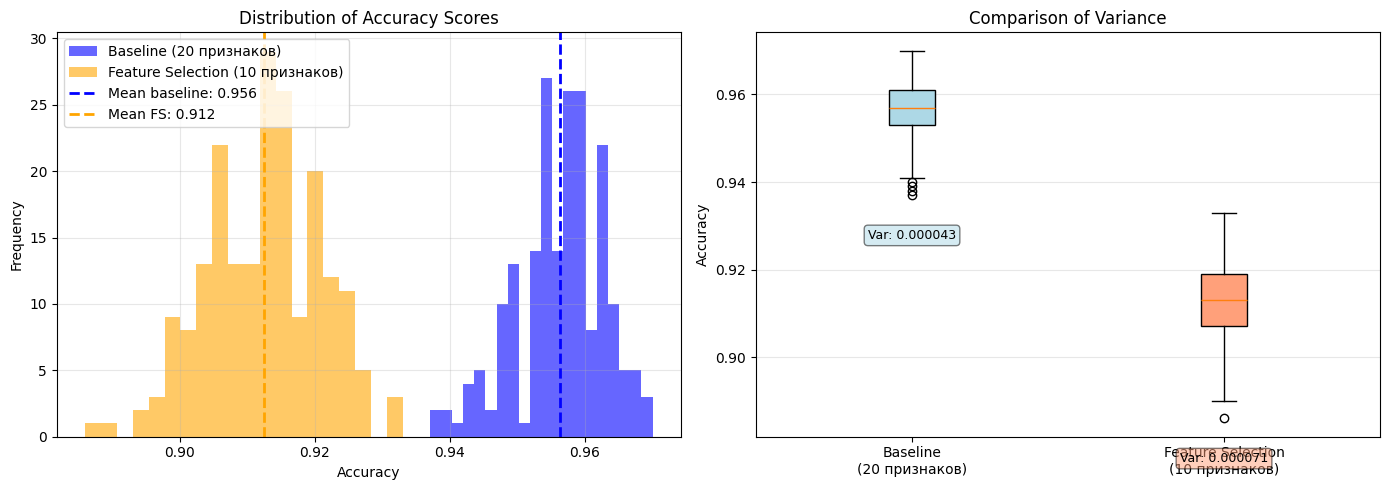

In [61]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(baseline_metrics, bins=20, alpha=0.6, label='Baseline (20 признаков)', color='blue')
axes[0].hist(fs_metrics, bins=20, alpha=0.6, label='Feature Selection (10 признаков)', color='orange')
axes[0].axvline(np.mean(baseline_metrics), color='blue', linestyle='--', linewidth=2, label=f'Mean baseline: {np.mean(baseline_metrics):.3f}')
axes[0].axvline(np.mean(fs_metrics), color='orange', linestyle='--', linewidth=2, label=f'Mean FS: {np.mean(fs_metrics):.3f}')
axes[0].set_xlabel('Accuracy')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Accuracy Scores')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

box_data = [baseline_metrics, fs_metrics]
bp = axes[1].boxplot(box_data, labels=['Baseline\n(20 признаков)', 'Feature Selection\n(10 признаков)'], 
                      patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightsalmon')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Comparison of Variance')
axes[1].grid(True, alpha=0.3, axis='y')

axes[1].text(1, min(baseline_metrics) - 0.01, f'Var: {baseline_var:.6f}', 
            ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[1].text(2, min(fs_metrics) - 0.01, f'Var: {fs_var:.6f}', 
            ha='center', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightsalmon', alpha=0.5))

plt.tight_layout()
plt.show()


### Вывод по RQ1

Feature selection уменьшает/не уменьшает дисперсию метрики качества при изменении random_state.

## RQ2: Uncertainty в регрессии

Строим график: как меняется точность модели, если делать предсказания только там, где модель уверена.

In [62]:

import pandas as pd
from sklearn.datasets import make_regression

np.random.seed(42)
n_features = 10
n_samples = 20000

data = make_regression(n_samples=n_samples, n_features=n_features, random_state=42)
df = pd.DataFrame(data[0], columns=[f'feature_{k}' for k in range(n_features)])
df['target'] = data[1]

print(f"Датасет создан: {df.shape}")
print(f"Признаки: {n_features}")
print(f"Объекты: {n_samples}")
df.head()


Датасет создан: (20000, 11)
Признаки: 10
Объекты: 20000


,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,target
0,-0.468520,0.170576,-1.292874,-0.504351,2.123321,-0.169730,-0.674621,0.786955,1.034668,-0.793705,-14.884048
1,-1.721784,-0.233479,1.083870,0.869204,0.702943,-0.922214,0.586586,0.989382,-0.622371,1.165433,118.101972
2,-1.091521,-1.565355,-0.665169,-1.868502,1.125179,0.970631,-1.190085,0.102027,0.309521,-0.992988,-195.447820
3,0.924589,-0.395053,1.059656,-1.870533,-1.291555,0.630429,-1.324491,1.987874,1.244477,-2.029877,149.192096
4,0.203883,-0.813505,0.159690,0.000644,-0.228327,-0.303422,1.125842,-1.461306,0.602785,0.290636,-144.642959


In [63]:

x_train, x_test, y_train, y_test = train_test_split(
    df.drop(['target'], axis=1), 
    df['target'], 
    test_size=0.3, 
    random_state=42
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, 
    test_size=0.2, 
    random_state=42
)

print(f"Train: {x_train.shape}")
print(f"Validation: {x_val.shape}")
print(f"Test: {x_test.shape}")


Train: (11200, 10)
Validation: (2800, 10)
Test: (6000, 10)


In [64]:
%%time

from catboost import CatBoostRegressor, Pool

train_pool = Pool(x_train, y_train)
val_pool = Pool(x_val, y_val)

model = CatBoostRegressor(
    loss_function='RMSEWithUncertainty',
    posterior_sampling=True,
    verbose=False, 
    random_seed=42,
    **catboost_gpu
)

model.fit(train_pool, eval_set=val_pool)


CPU times: user 11.5 s, sys: 4.74 s, total: 16.3 s
Wall time: 1.95 s


In [65]:

preds = model.virtual_ensembles_predict(
    x_test, 
    prediction_type='TotalUncertainty',
    virtual_ensembles_count=10
)

res = pd.DataFrame(
    preds, 
    columns=['predictions', 'knowledge_uncertainty', 'data_uncertainty'], 
    index=x_test.index
)
res['target'] = y_test
res['total_uncertainty'] = res['knowledge_uncertainty'] + res['data_uncertainty']

print("Предсказания с uncertainty получены!")
print(f"\nСтатистика uncertainty:")
print(res[['knowledge_uncertainty', 'data_uncertainty', 'total_uncertainty']].describe())
res.head()


Предсказания с uncertainty получены!

Статистика uncertainty:
       knowledge_uncertainty  data_uncertainty  total_uncertainty
count            6000.000000       6000.000000        6000.000000
mean                2.704135         68.711358          71.415493
std                 6.006783         87.184462          91.529319
min                 0.001808         12.317619          12.327519
25%                 0.178512         28.795890          29.370195
50%                 0.685122         42.666039          43.839433
75%                 2.379971         72.687706          75.732065
max                95.428274       1599.905847        1695.334121


,predictions,knowledge_uncertainty,data_uncertainty,target,total_uncertainty
10650,-199.310975,0.499811,33.680050,-204.809721,34.179861
2041,-135.067058,0.455858,31.595546,-129.508499,32.051404
8668,-32.752708,3.158513,32.320907,-36.108976,35.479420
1114,1.269333,0.104596,17.901015,-1.630234,18.005612
13902,-39.834124,0.602606,26.553909,-38.273008,27.156516


In [66]:

from sklearn.metrics import mean_squared_error, mean_absolute_error

baseline_mse = mean_squared_error(res['target'], res['predictions'])
baseline_mae = mean_absolute_error(res['target'], res['predictions'])

print(f"Базовая оценка на всей тестовой выборке:")
print(f"  MSE: {baseline_mse:.2f}")
print(f"  MAE: {baseline_mae:.2f}")
print(f"  RMSE: {np.sqrt(baseline_mse):.2f}")


Базовая оценка на всей тестовой выборке:
  MSE: 110.61
  MAE: 6.72
  RMSE: 10.52


In [67]:

number_unc_bins = 20
res['unc_bin'] = pd.qcut(res['total_uncertainty'], number_unc_bins, 
                         labels=range(0, number_unc_bins), duplicates='drop')

mse_by_threshold = []
mae_by_threshold = []
coverage_by_threshold = []

for threshold in range(number_unc_bins):
    filtered_res = res[res['unc_bin'] <= threshold]
    
    if len(filtered_res) > 0:
        mse = mean_squared_error(filtered_res['target'], filtered_res['predictions'])
        mae = mean_absolute_error(filtered_res['target'], filtered_res['predictions'])
        coverage = len(filtered_res) / len(res) * 100
        
        mse_by_threshold.append(mse)
        mae_by_threshold.append(mae)
        coverage_by_threshold.append(coverage)

print(f"Вычислено {len(mse_by_threshold)} точек для графика")
print(f"Охват выборки: от {min(coverage_by_threshold):.1f}% до {max(coverage_by_threshold):.1f}%")


Вычислено 20 точек для графика
Охват выборки: от 5.0% до 100.0%


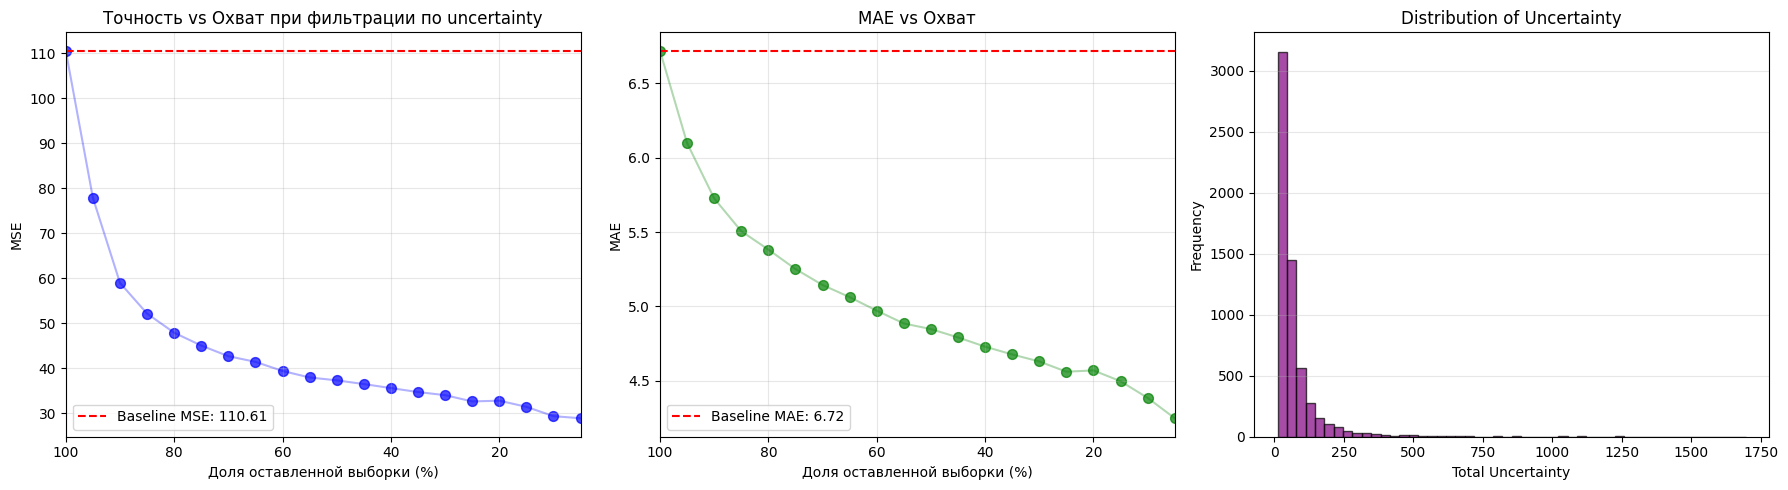

График показывает что если предсказывать только там, где модель уверена, (низкий uncertainty), то ошибка становится меньше!


In [71]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(coverage_by_threshold, mse_by_threshold, s=50, alpha=0.7, color='blue')
axes[0].plot(coverage_by_threshold, mse_by_threshold, alpha=0.3, color='blue')
axes[0].set_xlim(max(coverage_by_threshold), min(coverage_by_threshold))
axes[0].axhline(baseline_mse, color='red', linestyle='--', label=f'Baseline MSE: {baseline_mse:.2f}')
axes[0].set_xlabel('Доля оставленной выборки (%)')
axes[0].set_ylabel('MSE')
axes[0].set_title('Точность vs Охват при фильтрации по uncertainty')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(coverage_by_threshold, mae_by_threshold, s=50, alpha=0.7, color='green')
axes[1].plot(coverage_by_threshold, mae_by_threshold, alpha=0.3, color='green')
axes[1].set_xlim(max(coverage_by_threshold), min(coverage_by_threshold))
axes[1].axhline(baseline_mae, color='red', linestyle='--', label=f'Baseline MAE: {baseline_mae:.2f}')
axes[1].set_xlabel('Доля оставленной выборки (%)')
axes[1].set_ylabel('MAE')
axes[1].set_title('MAE vs Охват')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].hist(res['total_uncertainty'], bins=50, alpha=0.7, color='purple', edgecolor='black')
axes[2].set_xlabel('Total Uncertainty')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Distribution of Uncertainty')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("График показывает что если предсказывать только там, где модель уверена, (низкий uncertainty), то ошибка становится меньше!")


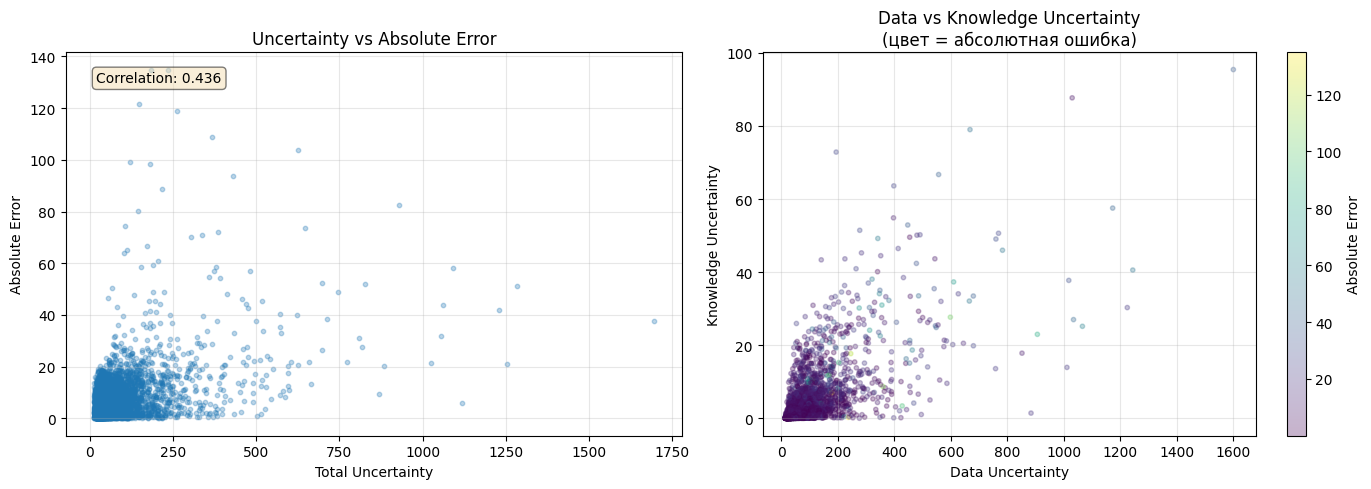


Корреляция между uncertainty и ошибкой: 0.436
Положительная корреляция означает что модель хорошо калибрована: где uncertainty выше - там и ошибка больше!


In [70]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

res['absolute_error'] = np.abs(res['target'] - res['predictions'])

axes[0].scatter(res['total_uncertainty'], res['absolute_error'], alpha=0.3, s=10)
axes[0].set_xlabel('Total Uncertainty')
axes[0].set_ylabel('Absolute Error')
axes[0].set_title('Uncertainty vs Absolute Error')
axes[0].grid(True, alpha=0.3)

correlation = np.corrcoef(res['total_uncertainty'], res['absolute_error'])[0, 1]
axes[0].text(0.05, 0.95, f'Correlation: {correlation:.3f}', 
            transform=axes[0].transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

axes[1].scatter(res['data_uncertainty'], res['knowledge_uncertainty'], alpha=0.3, s=10, c=res['absolute_error'], 
               cmap='viridis')
axes[1].set_xlabel('Data Uncertainty')
axes[1].set_ylabel('Knowledge Uncertainty')
axes[1].set_title('Data vs Knowledge Uncertainty\n(цвет = абсолютная ошибка)')
axes[1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[1].collections[0], ax=axes[1])
cbar.set_label('Absolute Error')

plt.tight_layout()
plt.show()

print(f"\nКорреляция между uncertainty и ошибкой: {correlation:.3f}")
print("Положительная корреляция означает что модель хорошо калибрована: где uncertainty выше - там и ошибка больше!")


### Вывод по RQ2

Чем меньше охват выборки (оставляем только уверенные предсказания), тем ниже ошибка.
Модель хорошо калибрована - высокий uncertainty соответствует высокой ошибке.

## Итого

**RQ1:** Feature selection влияет на стабильность оценки качества модели.

**RQ2:** Фильтрация по uncertainty позволяет улучшить точность за счёт охвата.